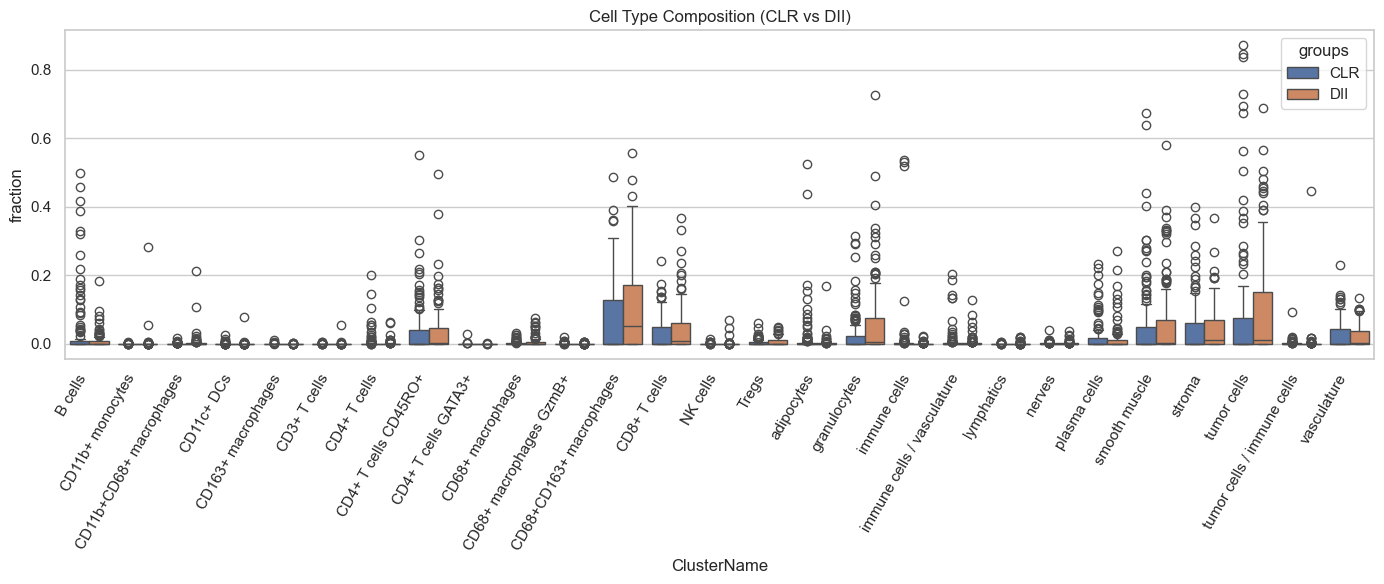

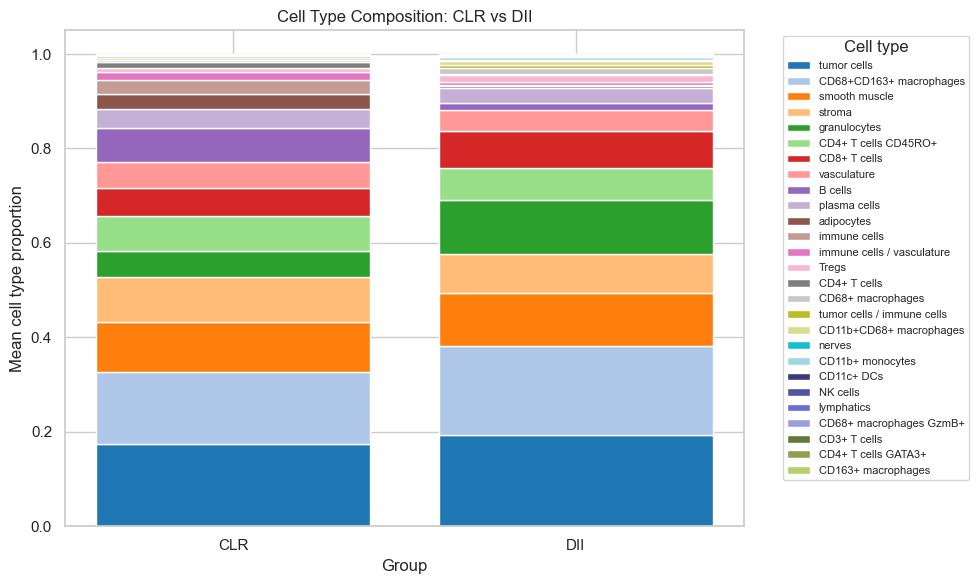

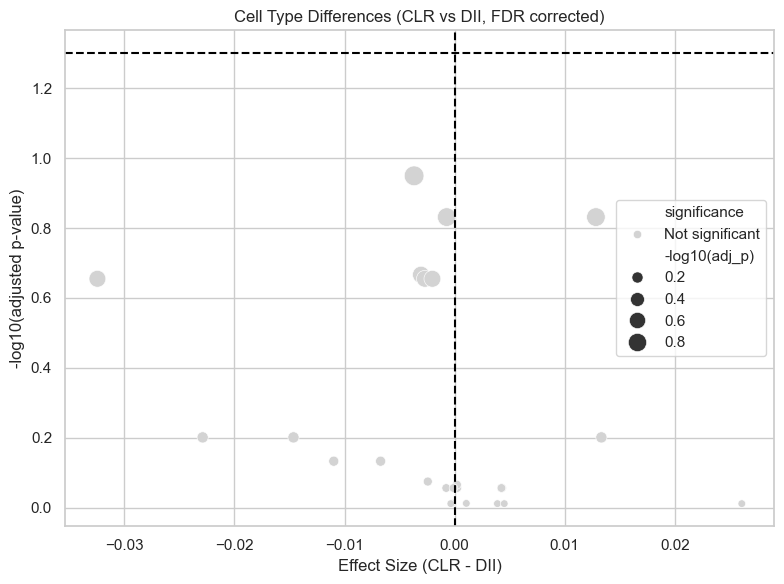

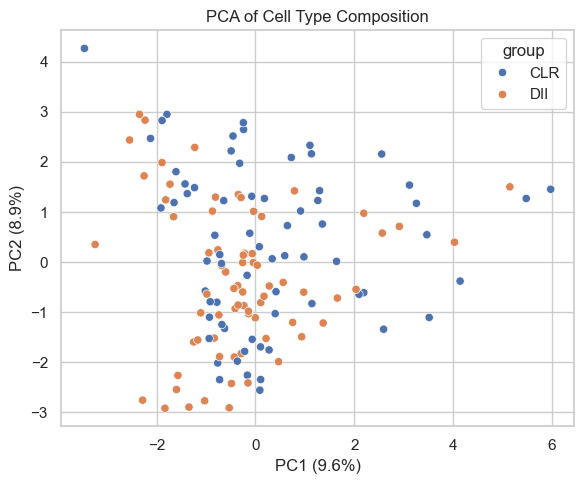

✅ Results saved:
- Supplementary_Table_S1_Cell_Type_Composition.xlsx
- All figures saved at 600 DPI


In [1]:
# =========================================
# CELL TYPE COMPOSITION ANALYSIS (CLR vs DII)
# =========================================

# =========================
# 0. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("CRC_clusters_neighborhoods_markers.csv")

df = df[["spots", "groups", "ClusterName"]].copy()
df = df[~df['ClusterName'].isin(['dirt', 'undefined'])]

df["groups"] = df["groups"].map({1: "CLR", 2: "DII"})

df["ClusterName"] = df["ClusterName"].astype("category")
df["groups"] = df["groups"].astype("category")

# =========================
# 2. CELL TYPE COUNTS PER SPOT
# =========================
comp = (
    df.groupby(["spots", "groups", "ClusterName"], observed=False)
      .size()
      .reset_index(name="count")
)

# =========================
# 3. FRACTION PER SPOT
# =========================
comp["fraction"] = comp["count"] / comp.groupby("spots")["count"].transform("sum")

# =========================
# 4. BOXPLOT
# =========================
plt.figure(figsize=(14,6))

sns.boxplot(
    data=comp,
    x="ClusterName",
    y="fraction",
    hue="groups"
)

plt.xticks(rotation=60, ha="right")
plt.title("Cell Type Composition (CLR vs DII)")
plt.tight_layout()

plt.savefig("Boxplot_Cell_Type_Composition.png", dpi=600)
plt.show()

# =========================
# 5. STATISTICAL TESTING
# =========================
results = []

for cell in comp["ClusterName"].unique():
    
    clr_vals = comp[
        (comp["ClusterName"] == cell) &
        (comp["groups"] == "CLR")
    ]["fraction"]
    
    dii_vals = comp[
        (comp["ClusterName"] == cell) &
        (comp["groups"] == "DII")
    ]["fraction"]

    if len(clr_vals) == 0 or len(dii_vals) == 0:
        continue

    if (clr_vals.sum() == 0 and dii_vals.sum() == 0):
        continue

    stat, p = mannwhitneyu(clr_vals, dii_vals, alternative="two-sided")

    results.append({
        "CellType": cell,
        "CLR_mean": clr_vals.mean(),
        "DII_mean": dii_vals.mean(),
        "p_value": p,
        "CLR_n": len(clr_vals),
        "DII_n": len(dii_vals)
    })

stats_df = pd.DataFrame(results)

# =========================
# 6. FDR CORRECTION
# =========================
stats_df["adj_p_value"] = multipletests(
    stats_df["p_value"], method="fdr_bh"
)[1]

# =========================
# 7. FLAGS + EFFECT SIZE
# =========================
stats_df["p_sig"] = stats_df["p_value"] < 0.05
stats_df["adj_p_sig"] = stats_df["adj_p_value"] < 0.05

stats_df["effect_size"] = stats_df["CLR_mean"] - stats_df["DII_mean"]

stats_df["-log10(p)"] = -np.log10(stats_df["p_value"])

# =========================
# 8. STACKED BARPLOT
# =========================
mean_comp = (
    comp.groupby(["groups", "ClusterName"], observed=False)["fraction"]
        .mean()
        .unstack()
        .fillna(0)
)

mean_comp = mean_comp.div(mean_comp.sum(axis=1), axis=0)
mean_comp = mean_comp.loc[["CLR", "DII"]]
mean_comp = mean_comp[mean_comp.mean().sort_values(ascending=False).index]

palette = (
    sns.color_palette("tab20") +
    sns.color_palette("tab20b") +
    sns.color_palette("tab20c")
)
colors = palette[:len(mean_comp.columns)]

plt.figure(figsize=(10,6))

bottom = np.zeros(len(mean_comp))

for i, cell_type in enumerate(mean_comp.columns):
    plt.bar(
        mean_comp.index,
        mean_comp[cell_type],
        bottom=bottom,
        label=cell_type,
        color=colors[i]
    )
    bottom += mean_comp[cell_type].values

plt.ylabel("Mean cell type proportion")
plt.xlabel("Group")
plt.title("Cell Type Composition: CLR vs DII")

plt.legend(
    title="Cell type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.savefig("Stacked_Bar_Plot_Cell_Type_Composition.png", dpi=600)
plt.show()

# =========================
# 9. VOLCANO PLOT
# =========================
plt.figure(figsize=(8,6))

stats_df["adj_p_value_safe"] = stats_df["adj_p_value"].replace(0, 1e-300)
stats_df["-log10(adj_p)"] = -np.log10(stats_df["adj_p_value_safe"])

stats_df["significance"] = "Not significant"
stats_df.loc[stats_df["adj_p_value"] < 0.05, "significance"] = "adj_p < 0.05"

sns.scatterplot(
    data=stats_df,
    x="effect_size",
    y="-log10(adj_p)",
    hue="significance",
    size="-log10(adj_p)",
    sizes=(30,200),
    palette={
        "Not significant": "lightgrey",
        "adj_p < 0.05": "red"
    }
)

plt.axhline(-np.log10(0.05), linestyle="--", color="black")
plt.axvline(0, linestyle="--", color="black")

for _, row in stats_df.iterrows():
    if (row["adj_p_value"] < 0.05) and (abs(row["effect_size"]) > 0.01):
        plt.text(
            row["effect_size"] + 0.001,
            row["-log10(adj_p)"] + 0.02,
            row["CellType"],
            fontsize=8
        )

plt.xlabel("Effect Size (CLR - DII)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Cell Type Differences (CLR vs DII, FDR corrected)")

plt.tight_layout()
plt.savefig("Volcano_Plot_Cell_Type_Composition.png", dpi=600)
plt.show()

# =========================
# 10. PCA
# =========================
comp_matrix = comp.pivot_table(
    index="spots",
    columns="ClusterName",
    values="fraction",
    fill_value=0,
    observed=False
)

group_map = df[["spots", "groups"]].drop_duplicates().set_index("spots")
comp_matrix["group"] = group_map.loc[comp_matrix.index]

X = comp_matrix.drop(columns="group")
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["group"] = comp_matrix["group"].values

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="group"
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Cell Type Composition")

plt.tight_layout()
plt.savefig("PCA_Cell_Type_Composition.png", dpi=600)
plt.show()

# =========================
# 11. SAVE TABLES TO EXCEL
# =========================
with pd.ExcelWriter("Supplementary_Table_S1_Cell_Type_Composition.xlsx") as writer:
    stats_df.to_excel(writer, sheet_name="Statistics", index=False)
    comp.to_excel(writer, sheet_name="PerSpot_Composition", index=False)

print("✅ Results saved:")
print("- Supplementary_Table_S1_Cell_Type_Composition.xlsx")
print("- All figures saved at 600 DPI")